In [1]:
# =========================
# Data Loading & Handling
# =========================
import pandas as pd
import numpy as np


# =========================
# Data Visualization (EDA)
# =========================
import matplotlib.pyplot as plt
import seaborn as sns


# =========================
# Data Preprocessing
# =========================
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    OneHotEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer


# =========================
# Regression Models
# =========================
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    RandomForestRegressor
)

from xgboost import XGBRegressor


# =========================
# Model Evaluation Metrics
# =========================
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# =========================
# Saving Models
# =========================
import joblib


# =========================
# Experiment Tracking (Optional)
# =========================
import mlflow
import mlflow.sklearn

In [2]:


# Read CSV file
data = pd.read_csv("loan_approval_dataset.csv")
data.head()




,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [3]:
data.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [5]:
data.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [6]:
data.columns = data.columns.str.replace(' ', '', regex=False)

In [7]:
# Remove extra spaces from object columns first
for col in ['self_employed', 'education', 'loan_status']:
    data[col] = data[col].str.strip()


# Convert categorical columns to numerical

data['self_employed'] = data['self_employed'].map({
    'Yes': 1,
    'No': 0
})

data['education'] = data['education'].map({
    'Graduate': 1,
    'Not Graduate': 0
})

data['loan_status'] = data['loan_status'].map({
    'Approved': 1,
    'Rejected': 0
})

In [8]:
data.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1
1,2,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,4,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0


In [9]:
data.shape

(4269, 13)

In [10]:
data.drop('loan_id', axis=1, inplace=True)

In [11]:
corr = data.corr()

corr['loan_amount'].sort_values(ascending=False)

loan_amount                 1.000000
income_annum                0.927470
luxury_assets_value         0.860914
bank_asset_value            0.788122
commercial_assets_value     0.603188
residential_assets_value    0.594596
loan_status                 0.016150
education                   0.010631
loan_term                   0.008437
self_employed               0.001450
no_of_dependents           -0.003366
cibil_score                -0.017035
Name: loan_amount, dtype: float64

In [12]:
corr = data.corr(numeric_only=True)['loan_amount']

C:\Users\ebtes\AppData\Local\Temp\ipykernel_9016\2722115924.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


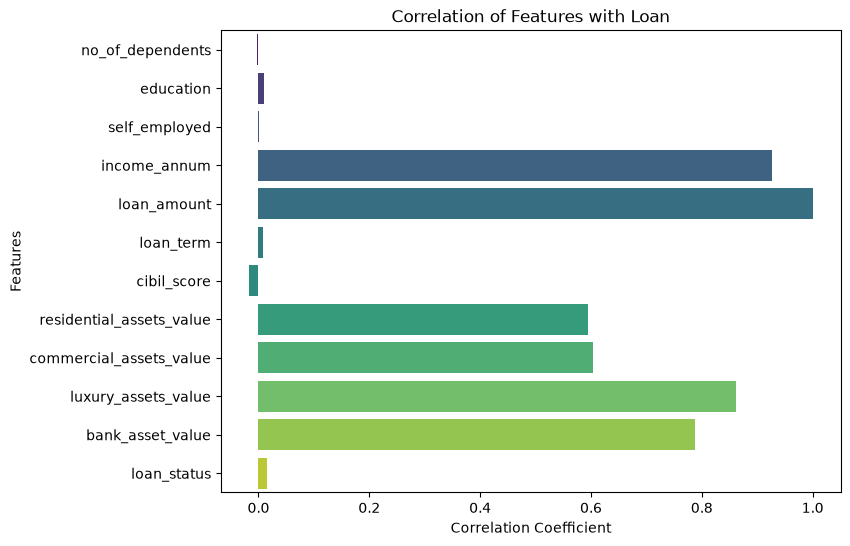

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,6))

sns.barplot(
    x=corr.values,
    y=corr.index,
    palette='viridis'
)

plt.title('Correlation of Features with Loan')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.show()

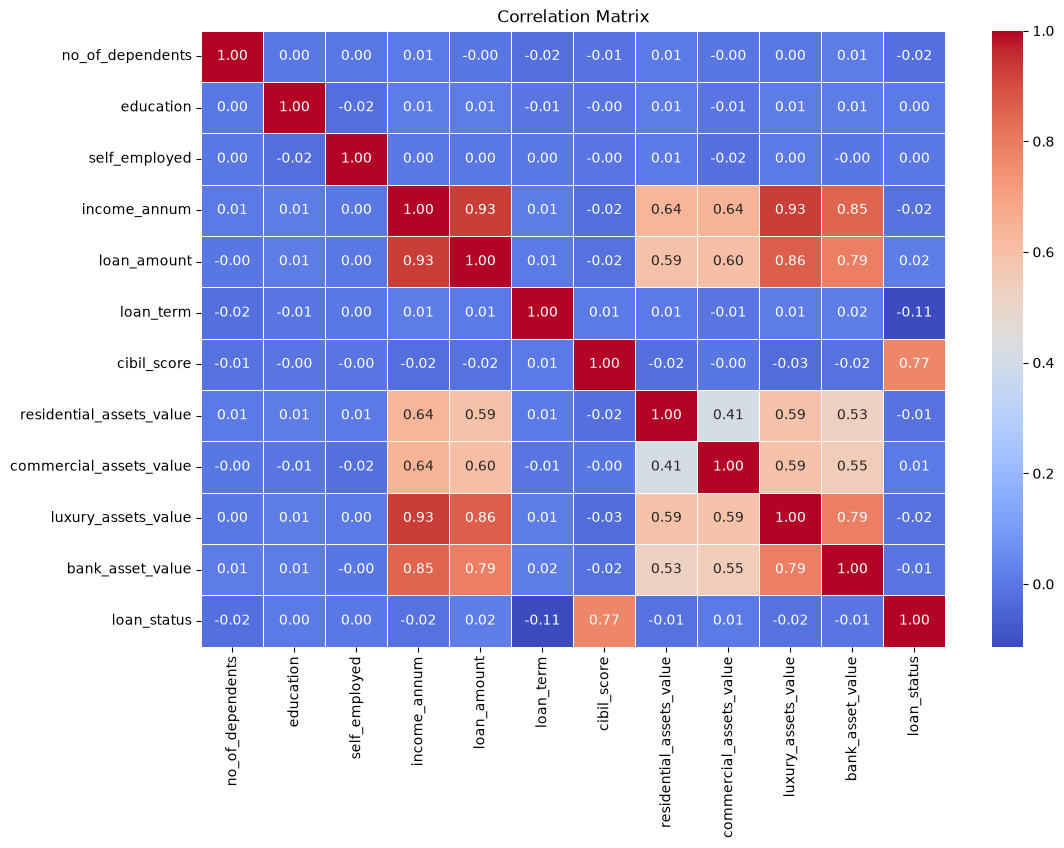

In [14]:
plt.figure(figsize=(12,8))

sns.heatmap(
    data.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Matrix')
plt.show()

In [15]:
numerical_cols = [
    "no_of_dependents",
    "income_annum",
    "loan_term",
    "cibil_score",
    "residential_assets_value",
    "commercial_assets_value",
    "luxury_assets_value",
    "bank_asset_value"
]

In [16]:
X = data.drop("loan_amount", axis=1)
y = data["loan_amount"]

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

Linear Regression Model

In [19]:
# Create model
lr = LinearRegression()

In [20]:
mlflow.set_experiment("reg_experiments")


2026/08/13 10:41:54 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/13 10:41:54 INFO mlflow.store.db.utils: Updating database tables
2026/08/13 10:41:55 INFO mlflow.tracking.fluent: Experiment with name 'reg_experiments' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:c:/Users/ebtes/OneDrive/Desktop/loan2/mlruns/1', creation_time=1786606915960, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1786606915960, lifecycle_stage='active', name='reg_experiments', tags={}, trace_location=None, workspace='default'>

In [21]:

mlflow.tracing.enable()

In [22]:
import mlflow
import mlflow.sklearn


from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mlflow.enable_system_metrics_logging()

with mlflow.start_run(run_name="Linear_Regression_Experiment1"):

    # Train model
    lr.fit(X_train, y_train)

    # Predictions
    y_pred = lr.predict(X_test)

    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = mse ** 0.5
    r2 = r2_score(y_test, y_pred)

    # Print metrics
    print("MAE  :", mae)
    print("MSE  :", mse)
    print("RMSE :", rmse)
    print("R²   :", r2)

    # Log model parameters
    mlflow.log_params(lr.get_params())

    # Log metrics
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("r2_score", r2)

    # Log Linear Regression model
    mlflow.sklearn.log_model(
        sk_model=lr,
        name="linear_regression_model",
        serialization_format="pickle"
    )

    # -----------------------------
    # Actual vs Predicted Plot
    # -----------------------------
    plt.figure(figsize=(8, 6))

    plt.scatter(y_test, y_pred, alpha=0.6)

    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        linestyle="--"
    )

    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title("Actual vs Predicted - Linear Regression")

    plt.tight_layout()
    plt.savefig(
        "actual_vs_predicted.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.close()

    mlflow.log_artifact("actual_vs_predicted.png")

    # -----------------------------
    # Residual Plot
    # -----------------------------
    residuals = y_test - y_pred

    plt.figure(figsize=(8, 6))

    plt.scatter(y_pred, residuals, alpha=0.6)

    plt.axhline(
        y=0,
        linestyle="--"
    )

    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")
    plt.title("Residual Plot - Linear Regression")

    plt.tight_layout()
    plt.savefig(
        "residual_plot.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.close()

    mlflow.log_artifact("residual_plot.png")

    # -----------------------------
    # Predictions CSV
    # -----------------------------
    predictions = pd.DataFrame({
        "Actual": y_test,
        "Predicted": y_pred
    })

    predictions.to_csv(
        "predictions.csv",
        index=False
    )

    mlflow.log_artifact("predictions.csv")

    # -----------------------------
    # Original Dataset
    # -----------------------------
    mlflow.log_artifact("loan_approval_dataset.csv")



2026/08/13 10:41:56 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/08/13 10:41:56 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/08/13 10:41:56 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


MAE  : 2598630.9583495418
MSE  : 11755022733744.094
RMSE : 3428559.862937221
R²   : 0.8534009252278945


2026/08/13 10:42:08 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/08/13 10:42:08 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


In [23]:
from sklearn.metrics import r2_score

y_pred_lr = lr.predict(X_test)

r2_lr = r2_score(y_test, y_pred_lr)

n = X_test.shape[0]
p = X_test.shape[1]

adjusted_lr = 1 - (1 - r2_lr) * (n - 1) / (n - p - 1)

print("R²:", r2_lr)
print("Adjusted R²:", adjusted_lr)

R²: 0.8534009252278945
Adjusted R²: 0.8514857354149572


Linear Regression Model With Stochastic Gradient Descent 

In [24]:
from sklearn.linear_model import SGDRegressor

model = SGDRegressor(
    max_iter=5000,
    learning_rate='adaptive',
    eta0=0.001,
    random_state=42
)


In [25]:
mlflow.enable_system_metrics_logging()

with mlflow.start_run(run_name="Linear_Regression_Experiment2"):

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = mse ** 0.5
    r2 = r2_score(y_test, y_pred)

    # Print metrics
    print("MAE  :", mae)
    print("MSE  :", mse)
    print("RMSE :", rmse)
    print("R²   :", r2)

    # Log parameters
    mlflow.log_params(model.get_params())

    # Log metrics
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("r2_score", r2)

    # Log model
    mlflow.sklearn.log_model(
        sk_model=model,
        name="sgd_regression_model",
        serialization_format="pickle"
    )

    # -----------------------------
    # Actual vs Predicted Plot
    # -----------------------------
    plt.figure(figsize=(8, 6))

    plt.scatter(
        y_test,
        y_pred,
        alpha=0.6,
        color="purple"
    )

    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color="black",
        linestyle="--"
    )

    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title("Actual vs Predicted - SGD Regression")

    plt.tight_layout()

    plt.savefig(
        "actual_vs_predicted_sgd.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    mlflow.log_artifact("actual_vs_predicted_sgd.png")

    # -----------------------------
    # Residual Plot
    # -----------------------------
    residuals = y_test - y_pred

    plt.figure(figsize=(8, 6))

    plt.scatter(
        y_pred,
        residuals,
        alpha=0.6,
        color="orange"
    )

    plt.axhline(
        y=0,
        color="black",
        linestyle="--"
    )

    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")
    plt.title("Residual Plot - SGD Regression")

    plt.tight_layout()

    plt.savefig(
        "residual_plot_sgd.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    mlflow.log_artifact("residual_plot_sgd.png")

    # -----------------------------
    # Predictions CSV
    # -----------------------------
    predictions = pd.DataFrame({
        "Actual": y_test,
        "Predicted": y_pred
    })

    predictions.to_csv(
        "predictions_sgd.csv",
        index=False
    )

    mlflow.log_artifact("predictions_sgd.csv")

    # -----------------------------
    # Original Dataset
    # -----------------------------
    mlflow.log_artifact("loan_approval_dataset.csv")

2026/08/13 10:42:08 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.


2026/08/13 10:42:08 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.


MAE  : 2598265.07517427
MSE  : 11751426061480.508
RMSE : 3428035.3063351763
R²   : 0.8534457799966213


2026/08/13 10:42:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/13 10:42:15 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/08/13 10:42:15 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


Linear Regression Model With Gridsearchcv

In [26]:


from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import GridSearchCV

mlflow.enable_system_metrics_logging()

with mlflow.start_run(
    run_name="SGD_Regression_GridSearch_Experiment3"
):

    # =================================
    # Pipeline
    # =================================

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("sgd", SGDRegressor(random_state=42))
    ])

    # =================================
    # Parameter Grid
    # =================================

    param_grid = {
        "sgd__max_iter": [1000, 3000, 5000, 10000],
        "sgd__learning_rate": ["constant", "adaptive"],
        "sgd__eta0": [0.0001, 0.001, 0.01],
        "sgd__penalty": ["l2", "l1", "elasticnet"]
    }

    # =================================
    # Grid Search
    # =================================

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=5,
        scoring="r2",
        n_jobs=-1
    )

    # Train GridSearch
    grid_search.fit(X_train, y_train)

    # =================================
    # Best Model
    # =================================

    best_sgd = grid_search.best_estimator_

    # =================================
    # Predictions
    # =================================

    y_pred = best_sgd.predict(X_test)

    # =================================
    # Metrics
    # =================================

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    # =================================
    # Print Results
    # =================================

    print("Best Parameters:")
    print(grid_search.best_params_)

    print("\nBest CV R²:")
    print(grid_search.best_score_)

    print("\nTuned SGD Regression Results")
    print("----------------------------")
    print("MAE :", mae)
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("R²  :", r2)

    # =================================
    # Log Parameters
    # =================================

    mlflow.log_params(
        grid_search.best_params_
    )

    # =================================
    # Log Metrics
    # =================================

    mlflow.log_metric(
        "best_cv_r2",
        grid_search.best_score_
    )

    mlflow.log_metric("mae", mae)
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("r2_score", r2)

    # =================================
    # Log Model
    # =================================

    mlflow.sklearn.log_model(
        sk_model=best_sgd,
        name="best_sgd_regression_model",
        serialization_format="pickle"
    )

    # =================================
    # Actual vs Predicted
    # =================================

    plt.figure(figsize=(8, 6))

    plt.scatter(
        y_test,
        y_pred,
        alpha=0.6
    )

    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        linestyle="--"
    )

    plt.xlabel("Actual Loan Amount")
    plt.ylabel("Predicted Loan Amount")
    plt.title("Actual vs Predicted - Tuned SGD Regression")

    plt.tight_layout()

    plt.savefig(
        "actual_vs_predicted_tuned_sgd.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    mlflow.log_artifact(
        "actual_vs_predicted_tuned_sgd.png"
    )

    # =================================
    # Residual Plot
    # =================================

    residuals = y_test - y_pred

    plt.figure(figsize=(8, 6))

    plt.scatter(
        y_pred,
        residuals,
        alpha=0.6
    )

    plt.axhline(
        y=0,
        linestyle="--"
    )

    plt.xlabel("Predicted Loan Amount")
    plt.ylabel("Residuals")
    plt.title("Residual Plot - Tuned SGD Regression")

    plt.tight_layout()

    plt.savefig(
        "residual_plot_tuned_sgd.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    mlflow.log_artifact(
        "residual_plot_tuned_sgd.png"
    )

    # =================================
    # Predictions CSV
    # =================================

    predictions = pd.DataFrame({
        "Actual": y_test,
        "Predicted": y_pred
    })

    predictions.to_csv(
        "predictions_tuned_sgd.csv",
        index=False
    )

    mlflow.log_artifact(
        "predictions_tuned_sgd.csv"
    )

    # =================================
    # Dataset
    # =================================

    mlflow.log_artifact(
        "loan_approval_dataset.csv"
    )

2026/08/13 10:42:15 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/08/13 10:42:15 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/08/13 10:42:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Best Parameters:
{'sgd__eta0': 0.001, 'sgd__learning_rate': 'constant', 'sgd__max_iter': 1000, 'sgd__penalty': 'l1'}

Best CV R²:
0.8632406161021299

Tuned SGD Regression Results
----------------------------
MAE : 2599543.9527400597
MSE : 11754349163444.389
RMSE: 3428461.6321966313
R²  : 0.8534093254483761


2026/08/13 10:42:44 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/08/13 10:42:44 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


RandomForestRegressor model

In [27]:
from sklearn.ensemble import RandomForestRegressor

In [28]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

In [29]:


mlflow.enable_system_metrics_logging()

with mlflow.start_run(
    run_name="Random_Forest_Regression_Experiment1"
):


    # Train Model
  

    rf.fit(X_train, y_train)

   

    y_pred = rf.predict(X_test)

 
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)


    print("Random Forest Regression Results")
    print("--------------------------------")
    print("MAE :", mae)
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("R²  :", r2)

    # Log Parameters


    mlflow.log_params({
        "n_estimators": 200,
        "max_depth": None,
        "min_samples_split": 2,
        "min_samples_leaf": 1,
        "random_state": 42
    })


    # Log Metrics


    mlflow.log_metric("mae", mae)
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("r2_score", r2)

    
    # Log Model

    mlflow.sklearn.log_model(
        sk_model=rf,
        name="random_forest_regression_model",
        serialization_format="pickle"
    )

 
    # Actual vs Predicted
   

    plt.figure(figsize=(8, 6))

    plt.scatter(
        y_test,
        y_pred,
        alpha=0.6
    )

    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        linestyle="--"
    )

    plt.xlabel("Actual Loan Amount")
    plt.ylabel("Predicted Loan Amount")
    plt.title("Actual vs Predicted - Random Forest Regression")

    plt.tight_layout()

    plt.savefig(
        "actual_vs_predicted_random_forest.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    mlflow.log_artifact(
        "actual_vs_predicted_random_forest.png"
    )

 
    # Residual Plot
  

    residuals = y_test - y_pred

    plt.figure(figsize=(8, 6))

    plt.scatter(
        y_pred,
        residuals,
        alpha=0.6
    )

    plt.axhline(
        y=0,
        linestyle="--"
    )

    plt.xlabel("Predicted Loan Amount")
    plt.ylabel("Residuals")
    plt.title("Residual Plot - Random Forest Regression")

    plt.tight_layout()

    plt.savefig(
        "residual_plot_random_forest.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    mlflow.log_artifact(
        "residual_plot_random_forest.png"
    )

    #
    # Feature Importance


    feature_importance = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": rf.feature_importances_
    }).sort_values(
        by="Importance",
        ascending=False
    )

    plt.figure(figsize=(10, 6))

    plt.barh(
        feature_importance["Feature"],
        feature_importance["Importance"]
    )

    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title("Random Forest Feature Importance")

    plt.gca().invert_yaxis()

    plt.tight_layout()

    plt.savefig(
        "feature_importance_random_forest.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    mlflow.log_artifact(
        "feature_importance_random_forest.png"
    )

 
    # Feature Importance CSV


    feature_importance.to_csv(
        "feature_importance_random_forest.csv",
        index=False
    )

    mlflow.log_artifact(
        "feature_importance_random_forest.csv"
    )

   
    # Predictions CSV

    predictions = pd.DataFrame({
        "Actual": y_test,
        "Predicted": y_pred
    })

    predictions.to_csv(
        "predictions_random_forest.csv",
        index=False
    )

    mlflow.log_artifact(
        "predictions_random_forest.csv"
    )

    # Dataset


    mlflow.log_artifact(
        "loan_approval_dataset.csv"
    )

2026/08/13 10:42:44 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/08/13 10:42:44 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/08/13 10:42:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Random Forest Regression Results
--------------------------------
MAE : 2595884.6604215456
MSE : 12042703983313.816
RMSE: 3470259.9302233565
R²  : 0.8498131988600721


2026/08/13 10:42:52 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/08/13 10:42:52 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


RandomForestRegressor model with gridsearch

In [30]:


from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV


mlflow.enable_system_metrics_logging()

with mlflow.start_run(
    run_name="Random_Forest_Regression_GridSearch_Experiment2"
):

 

    rf = RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    )

 

    param_grid = {
        "n_estimators": [100, 200, 300],
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    }

   

    grid_search = GridSearchCV(
        estimator=rf,
        param_grid=param_grid,
        cv=5,
        scoring="r2",
        n_jobs=-1
    )

    # Train GridSearch
    grid_search.fit(X_train, y_train)



    best_rf = grid_search.best_estimator_

 

    y_pred = best_rf.predict(X_test)



    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)



    print("Best Parameters:")
    print(grid_search.best_params_)

    print("\nBest CV R²:")
    print(grid_search.best_score_)

    print("\nTuned Random Forest Regression Results")
    print("--------------------------------------")
    print("MAE :", mae)
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("R²  :", r2)


    mlflow.log_params(
        grid_search.best_params_
    )

    mlflow.log_metric(
        "best_cv_r2",
        grid_search.best_score_
    )

    mlflow.log_metric("mae", mae)
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("r2_score", r2)

    

    mlflow.sklearn.log_model(
        sk_model=best_rf,
        name="best_random_forest_regression_model",
        serialization_format="pickle"
    )


    plt.figure(figsize=(8, 6))

    plt.scatter(
        y_test,
        y_pred,
        alpha=0.6
    )

    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        linestyle="--"
    )

    plt.xlabel("Actual Loan Amount")
    plt.ylabel("Predicted Loan Amount")
    plt.title(
        "Actual vs Predicted - Tuned Random Forest Regression"
    )

    plt.tight_layout()

    plt.savefig(
        "actual_vs_predicted_tuned_random_forest.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    mlflow.log_artifact(
        "actual_vs_predicted_tuned_random_forest.png"
    )


    residuals = y_test - y_pred

    plt.figure(figsize=(8, 6))

    plt.scatter(
        y_pred,
        residuals,
        alpha=0.6
    )

    plt.axhline(
        y=0,
        linestyle="--"
    )

    plt.xlabel("Predicted Loan Amount")
    plt.ylabel("Residuals")
    plt.title(
        "Residual Plot - Tuned Random Forest Regression"
    )

    plt.tight_layout()

    plt.savefig(
        "residual_plot_tuned_random_forest.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    mlflow.log_artifact(
        "residual_plot_tuned_random_forest.png"
    )

  
    feature_importance = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": best_rf.feature_importances_
    }).sort_values(
        by="Importance",
        ascending=False
    )

    plt.figure(figsize=(10, 6))

    plt.barh(
        feature_importance["Feature"],
        feature_importance["Importance"]
    )

    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title(
        "Feature Importance - Tuned Random Forest"
    )

    plt.gca().invert_yaxis()

    plt.tight_layout()

    plt.savefig(
        "feature_importance_tuned_random_forest.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    mlflow.log_artifact(
        "feature_importance_tuned_random_forest.png"
    )

    

    feature_importance.to_csv(
        "feature_importance_tuned_random_forest.csv",
        index=False
    )

    mlflow.log_artifact(
        "feature_importance_tuned_random_forest.csv"
    )


    predictions = pd.DataFrame({
        "Actual": y_test,
        "Predicted": y_pred
    })

    predictions.to_csv(
        "predictions_tuned_random_forest.csv",
        index=False
    )

    mlflow.log_artifact(
        "predictions_tuned_random_forest.csv"
    )

 

    mlflow.log_artifact(
        "loan_approval_dataset.csv"
    )

2026/08/13 10:42:52 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/08/13 10:42:52 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/08/13 10:45:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}

Best CV R²:
0.8579337330105699

Tuned Random Forest Regression Results
--------------------------------------
MAE : 2589218.089499914
MSE : 11861316151153.906
RMSE: 3444026.154249399
R²  : 0.8520753202503802


2026/08/13 10:45:17 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/08/13 10:45:17 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


In [31]:
train_pred = best_rf.predict(X_train)
train_r2 = r2_score(y_train, train_pred)

print("Train R²:", train_r2)
print("CV R²:", grid_search.best_score_)
print("Test R²:", r2)

Train R²: 0.9297645823530991
CV R²: 0.8579337330105699
Test R²: 0.8520753202503802


Compared with Random Forest after GridSearchCV, SGD performed slightly better overall, achieving an R² of 85.34% and an RMSE of approximately 3.43 million, while Random Forest achieved an R² of 85.22% and an RMSE of approximately 3.44 million. Although Random Forest had a slightly lower MAE, the better R² and RMSE of SGD suggest that most of the important relationships between the features and loan_amount are approximately linear. Therefore, linear models such as Linear Regression and SGD performed slightly better than Random Forest on this dataset.